# SARS-CoV-2 ascertainment: what fraction of infections were sequenced, and what fraction were reported?

**Window: 2020-03 through 2022-06** — the least-controlled stretch of the pandemic. National (US) and Virginia.

Two headline quantities, both built from CDC surveillance data in the shared commons:

| Quantity | Numerator | Denominator |
|---|---|---|
| `frac_infections_sequenced` | genomes collected | infections inferred from anti-N seroprevalence |
| `frac_cases_sequenced` | genomes collected | reported cases |
| `case_ascertainment` | reported cases | infections inferred from anti-N seroprevalence |

The three are linked: `frac_infections_sequenced = frac_cases_sequenced x case_ascertainment`.

### Data sources actually used

| Series | Source | Resolution | Coverage |
|---|---|---|---|
| Sequences | `data/variants/all_variants.csv` (outbreak.info / GISAID) | daily x state | 2020-03 – 2025-10 |
| Sequences (VA check) | `VDH_genomics/Genomic Data NCBI` | per specimen | 2020 – 2024 |
| Infections | CDC Commercial Lab Seroprevalence (`d2tw-32xv`) anti-N | ~biweekly x state | rounds 1–30, 2020-07 – 2022-02 |
| Infections (2022 tail) | CDC Blood Donor Survey 2022–23 (`ar8q-3jhn`) | quarterly x state | 2022-Q1 – 2023-Q4 |
| Infections (national alt) | CDC Blood Donor 2020–21 infection-induced (`mtc3-kq6r`) | monthly x region | 2020-07 – 2021-12 |
| Reported cases | CDC weekly cases/deaths by state (`pwn4-m3yp`) | weekly x state | 2020-01 – 2023-05 |
| Reported cases (alt) | CDC case surveillance aggregate `PU_linelist_agg_cases.csv` | monthly x county | 2020-01 – 2022-07 |
| Hospitalisations | NHSN weekly by jurisdiction (`aemt-mg7g`) | weekly x state | 2020-08 – 2024-10 |
| Variant shares | CDC SARS-CoV-2 Variant Proportions (`jr58-6ysp`) | weekly x USA/HHS region | 2021-01 – 2024-12 |
| ED visits (out of window) | NSSP trajectories (`rdmq-nq56`) | weekly x state/sub-state | 2022-10 – 2024-12 |

### Two things that did not work out, and why

**NSSP ED visits still do not reach this window, but they start a year earlier than the summary file suggests.** The NSSP
*summary* file (`vutn-jzwm`) begins 2023-10-07; the NSSP *trajectories* file (`rdmq-nq56`) begins **2022-10-01**. Either way the
series starts after mid-2022, so NSSP cannot contribute to ascertainment in this window — but it overlaps the CDC weekly case
series by 33 weeks, which is enough to calibrate the two against each other for work extending past 2022 (section 9). Where a
healthcare-seeking signal is wanted for the early period, `COVIDcast/doctor-visits_smoothed_adj_cli_county.csv` covers it — but
it is *outpatient* CLI, not ED visits, so it is a proxy rather than a substitute. NHSN hospital admissions are used instead as
the severity anchor.

**CDC Variant Proportions has no sequence counts.** It publishes weighted lineage *shares* only, for USA and the 10 HHS
regions (Virginia is in Region 3) — no state resolution and no denominators. It is used here for variant-era context, not
for the sequencing fraction. The counts come from outbreak.info/GISAID instead.

In [1]:
cd bi_bl4zc/pgcoe_genepi_analytics/notebooks/

[Errno 2] No such file or directory: 'bi_bl4zc/pgcoe_genepi_analytics/notebooks/'
/sfs/gpfs/tardis/project/bii_nssac/people/bl4zc/pgcoe_genepi_analytics/notebooks


In [2]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter, FuncFormatter, NullFormatter

sys.path.insert(0, '.')
import ascertainment_data as ad

try:                                    # so the notebook also runs as a script
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
})

RESULTS = f'{ad.WORKING_DIR}/data/results/ascertainment'
os.makedirs(RESULTS, exist_ok=True)

# Palette held constant across every figure in the notebook.
COL = {'sequences': '#4C6EF5', 'cases': '#F08C00', 'infections': '#12866E',
       'hosp': '#C2255C', 'us': '#4C6EF5', 'va': '#C2255C'}
ERA_SHADE = ['#F8F9FA', '#EDF2FF', '#F8F9FA', '#EDF2FF', '#F8F9FA']
ERA_NAMES = [n for n, _, _ in ad.VARIANT_ERAS]
ERA_SHORT = ['Ancestral', 'Alpha', 'Delta', 'BA.1', 'BA.2/BA.5']
print('ready')

ready


## 1. Coverage check

Before building anything, confirm what each series actually spans. This is the step that ruled NSSP out.

In [3]:
def _span(s):
    s = s.dropna()
    return (s.index.min(), s.index.max()) if len(s) else (pd.NaT, pd.NaT)

rows = []
for geo in ['US', 'VA']:
    seq = ad.load_sequence_counts(geo)['n_sequences']
    rows.append(('sequences (GISAID)', geo, *_span(seq), f'{seq.sum():,.0f} genomes'))

wc = ad.load_weekly_cases_deaths()
rows.append(('reported cases', 'US/state', wc.end_date.min(), wc.end_date.max(), f'{len(wc):,} state-weeks'))

cs = ad.load_case_surveillance_monthly()
rows.append(('case surveillance agg', 'county', cs.month.min(), cs.month.max(), f'{cs["count"].sum():,.0f} cases'))

hosp = ad.load_hospitalizations()
rows.append(('NHSN admissions', 'US/state', hosp.week_end_date.min(), hosp.week_end_date.max(), f'{len(hosp):,} rows'))

cl = ad.load_commercial_lab_seroprevalence()
cln = cl[cl.anti_n_pct.notna()]
rows.append(('commercial lab anti-N', '50 st + DC + PR + US', cln.specimen_mid.min(), cln.specimen_mid.max(),
             f'rounds {cln["round"].min()}-{cln["round"].max()}'))

bd = ad.load_blood_donor_infection_induced()
rows.append(('blood donor anti-N 20-21', 'donor regions', bd.month.min(), bd.month.max(), f'{bd.region.nunique()} regions'))

bd22 = ad.fetch_blood_donor_2022_2023()
rows.append(('blood donor 22-23', 'state + USA', bd22.quarter_mid.min(), bd22.quarter_mid.max(),
             f'{bd22.time_period.nunique()} quarters'))

vp = ad.load_cdc_variant_proportions('USA')
rows.append(('CDC variant shares', 'USA + HHS regions', vp.week_ending.min(), vp.week_ending.max(), 'shares only, no counts'))

nssp = ad.load_nssp_ed_visits()
rows.append(('NSSP ED visits (summary)', 'state', nssp.week_end.min(), nssp.week_end.max(),
             'starts after window'))

traj = ad.load_nssp_ed_trajectories()
rows.append(('NSSP ED visits (trajectories)', 'state + sub-state', traj.week_end.min(), traj.week_end.max(),
             'starts after window; overlaps cases'))

cov = pd.DataFrame(rows, columns=['series', 'geography', 'start', 'end', 'note'])
cov['covers_window'] = (cov.start <= ad.WINDOW_END) & (cov.end >= ad.WINDOW_START)
cov

,series,geography,start,end,note,covers_window
0,sequences (GISAID),US,2020-03-01 00:00:00,2025-10-02 00:00:00,"5,284,121 genomes",True
1,sequences (GISAID),VA,2020-03-06 00:00:00,2025-09-24 00:00:00,"103,912 genomes",True
2,reported cases,US/state,2020-01-22 00:00:00,2023-05-10 00:00:00,"10,380 state-weeks",True
3,case surveillance agg,county,2020-01-01 00:00:00,2022-07-01 00:00:00,"54,621,323 cases",True
4,NHSN admissions,US/state,2020-08-08 00:00:00,2024-10-26 00:00:00,442 rows,True
5,commercial lab anti-N,50 st + DC + PR + US,2020-07-31 12:00:00,2022-02-16 12:00:00,rounds 1-30,True
6,blood donor anti-N 20-21,donor regions,2020-07-01 00:00:00,2021-12-01 00:00:00,71 regions,True
7,blood donor 22-23,state + USA,2022-02-15 00:00:00,2023-11-15 00:00:00,7 quarters,True
8,CDC variant shares,USA + HHS regions,2021-01-02 00:00:00,2024-11-23 00:00:00,"shares only, no counts",True
9,NSSP ED visits (summary),state,2023-10-07 00:00:00,2024-12-28 00:00:00,starts after window,False


`covers_window` is False for exactly the two NSSP rows. The two NSSP datasets do **not** share a start date — the trajectories
file reaches back to 2022-10-01, a year before the summary file. Neither reaches mid-2022.

## 2. Building the infection denominator

Reported cases and sequences are counted directly. Infections are not — they have to be inferred from cumulative
anti-nucleocapsid (anti-N) seroprevalence, which is only measured at survey rounds. Four corrections are applied
in `ascertainment_data.cumulative_infections_from_seroprevalence`:

1. **Seroconversion lag (21 d).** The survey measures antibodies, which appear ~3 weeks after infection. Without
   shifting the curve back, the denominator lags the numerator and case ascertainment exceeds 1 at wave onsets.
2. **Monotone cubic (PCHIP) interpolation.** Rounds are irregular — there is a three-month gap between rounds 24 and 26.
   Linear interpolation turns those gaps into flat stretches (spurious zero-infection months) followed by step jumps.
3. **Non-decreasing enforcement**, so sampling noise cannot produce negative incidence.
4. **Optional seroreversion correction.** Anti-N antibodies wane, so a cumulative curve *understates* cumulative
   infection, increasingly so over time. This is the single largest source of uncertainty here and is treated as a
   sensitivity below rather than a calibrated correction.

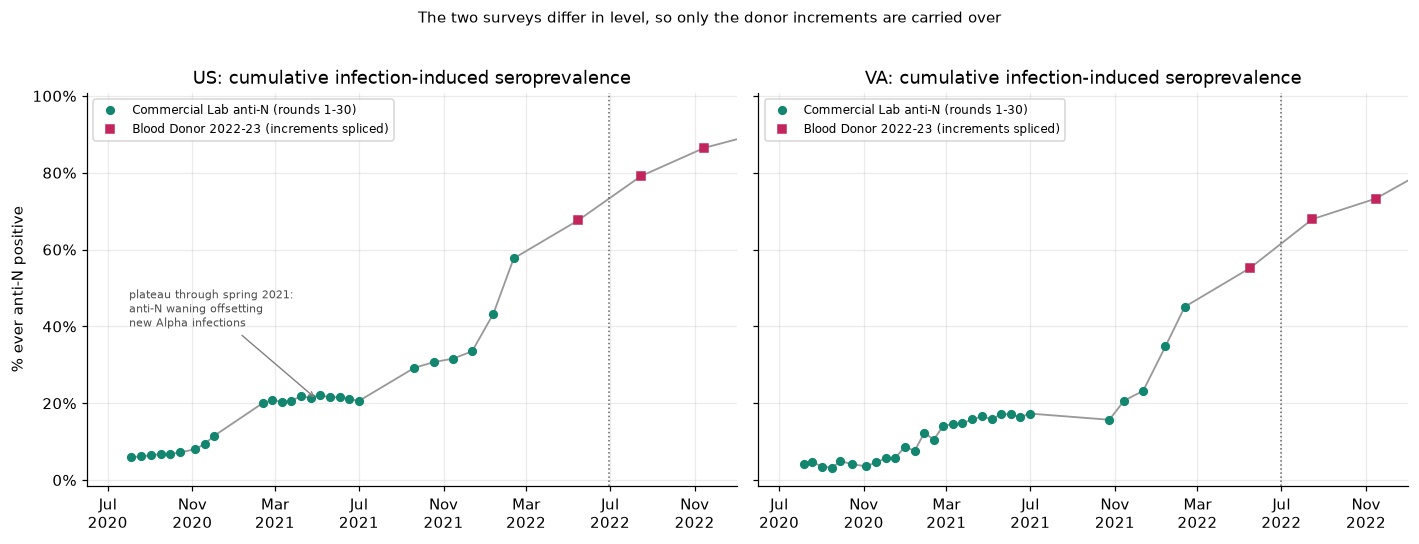

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, geo in zip(axes, ['US', 'VA']):
    sero, src = ad.seroprevalence_series(geo)
    # Continuous line first so the splice reads as one curve, markers on top to
    # show which survey each point came from.
    ax.plot(sero.index, sero.values, '-', lw=1.2, color='0.6', zorder=1)
    for name, mark, colr, lab in [
            ('commercial_lab', 'o', COL['infections'], 'Commercial Lab anti-N (rounds 1-30)'),
            ('blood_donor_2022', 's', COL['hosp'], 'Blood Donor 2022-23 (increments spliced)')]:
        m = (src == name).to_numpy()
        ax.plot(sero.index[m], sero.values[m], mark, ms=5, color=colr, label=lab, zorder=2)
    ax.axvline(ad.WINDOW_END, color='0.4', ls=':', lw=1)
    ax.set_title(f'{geo}: cumulative infection-induced seroprevalence')
    ax.set_xlim(pd.Timestamp('2020-06-01'), pd.Timestamp('2023-01-01'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.legend(fontsize=8, loc='upper left')

axes[0].set_ylabel('% ever anti-N positive')
axes[0].yaxis.set_major_formatter(PercentFormatter(100))
axes[0].annotate('plateau through spring 2021:\nanti-N waning offsetting\nnew Alpha infections',
                 xy=(pd.Timestamp('2021-05-01'), 21), xytext=(pd.Timestamp('2020-08-01'), 40),
                 fontsize=7.5, color='0.3',
                 arrowprops=dict(arrowstyle='->', color='0.5', lw=.9))
fig.suptitle('The two surveys differ in level, so only the donor increments are carried over', y=1.02, fontsize=10)
fig.tight_layout()
fig.savefig(f'{RESULTS}/seroprevalence_splice.png', bbox_inches='tight')
plt.show()

The commercial-lab and blood-donor surveys sit ~9 points apart at the join (57.7% vs 48.8% nationally) because clinical-lab
remnant specimens come from people with more healthcare contact than volunteer blood donors. Splicing the donor *levels* on
would create a false drop; splicing its *increments* uses it only for what is needed — how much cumulative infection rose
after Feb 2022.

## 3. Monthly panel

`build_monthly_panel` assembles sequences, cases, hospitalisations and inferred infections onto a common monthly index.
Monthly is the honest ceiling on resolution: the seroprevalence rounds that anchor infections are roughly monthly.

From here on the analysis carries **three labelled series**, so the two Virginia genome sources stay visibly distinct:

| Label | Geography | Genome source |
|---|---|---|
| `US · GISAID` | national | outbreak.info / GISAID deposits |
| `VA · GISAID` | Virginia | outbreak.info / GISAID deposits |
| `VA · reconciled` | Virginia | VDH reconciled NCBI/GISAID/in-state list (section 7) |

The two VA series share **every denominator** — infections, reported cases, hospital admissions are the same numbers.
They differ only in the genome count, so only `n_sequences`, `frac_infections_sequenced` and `frac_cases_sequenced` move
between them. `case_ascertainment` is identical by construction and is never plotted twice.

The central estimate uses a **365-day anti-N half-life**. Section 6 shows what changes if that assumption moves.

In [5]:
HALFLIFE = 365   # central assumption for anti-N seroreversion

# label -> (geography, genome source)
SERIES = {
    'US · GISAID':     ('US', 'gisaid'),
    'VA · GISAID':     ('VA', 'gisaid'),
    'VA · reconciled': ('VA', 'reconciled'),
}
SERIES_COLORS = {'US · GISAID': COL['us'], 'VA · GISAID': COL['va'],
                 'VA · reconciled': COL['infections']}
# Where genome counts are drawn alongside infections and admissions, the series
# palette would collide with them, so genome *sources* get their own two colours.
GENOME_COLORS = {'GISAID': COL['sequences'], 'reconciled': '#862E9C'}
#: Ratios that actually depend on which genome source is used.
SEQ_METRICS = ['n_sequences', 'frac_infections_sequenced', 'frac_cases_sequenced']

panels = {lab: ad.build_monthly_panel(geo, seroreversion_halflife_days=HALFLIFE,
                                      sequence_source=src)
          for lab, (geo, src) in SERIES.items()}
eras = {lab: ad.build_era_panel(panels[lab], geo, seroreversion_halflife_days=HALFLIFE)
        for lab, (geo, src) in SERIES.items()}

show = ['n_sequences', 'reported_cases', 'hosp_admissions', 'infections',
        'frac_infections_sequenced', 'frac_cases_sequenced', 'case_ascertainment']
panels['US · GISAID'][show].round(4)

,n_sequences,reported_cases,hosp_admissions,infections,frac_infections_sequenced,frac_cases_sequenced,case_ascertainment
month,,,,,,,
2020-03-01,15884.0,68140.0,NaN,NaN,NaN,0.2331,NaN
2020-04-01,17907.0,973028.0,NaN,NaN,NaN,0.0184,NaN
2020-05-01,13034.0,650546.0,NaN,NaN,NaN,0.0200,NaN
2020-06-01,16034.0,654502.0,NaN,NaN,NaN,0.0245,NaN
2020-07-01,24378.0,1984941.0,NaN,NaN,NaN,0.0123,NaN
2020-08-01,16081.0,1451550.0,116351.0,3.043429e+06,0.0053,0.0111,0.4769
2020-09-01,17160.0,1403773.0,95246.0,3.431916e+06,0.0050,0.0122,0.4090
2020-10-01,28015.0,1618035.0,172558.0,9.496921e+06,0.0029,0.0173,0.1704
2020-11-01,39886.0,3914027.0,277878.0,1.642481e+07,0.0024,0.0102,0.2383


In [6]:
# Virginia: shared denominators once, then each genome source's own columns.
va_g, va_r = panels['VA · GISAID'], panels['VA · reconciled']
assert va_g.case_ascertainment.equals(va_r.case_ascertainment)   # denominators are shared

va = pd.DataFrame({
    'reported_cases': va_g.reported_cases,
    'hosp_admissions': va_g.hosp_admissions,
    'infections': va_g.infections,
    'case_ascertainment': va_g.case_ascertainment,
    'n_seq · GISAID': va_g.n_sequences,
    'n_seq · reconciled': va_r.n_sequences,
    'seq/inf · GISAID': va_g.frac_infections_sequenced,
    'seq/inf · reconciled': va_r.frac_infections_sequenced,
})
va.round(4)

,n_sequences,reported_cases,hosp_admissions,infections,frac_infections_sequenced,frac_cases_sequenced,case_ascertainment
month,,,,,,,
2020-03-01,151.0,395.0,NaN,NaN,NaN,0.3823,NaN
2020-04-01,392.0,14566.0,NaN,NaN,NaN,0.0269,NaN
2020-05-01,226.0,25285.0,NaN,NaN,NaN,0.0089,NaN
2020-06-01,147.0,19258.0,NaN,NaN,NaN,0.0076,NaN
2020-07-01,200.0,28486.0,NaN,NaN,NaN,0.0070,NaN
2020-08-01,189.0,27469.0,1568.0,3.591734e+04,0.0053,0.0069,0.7648
2020-09-01,149.0,32811.0,1672.0,3.650226e+04,0.0041,0.0045,0.8989
2020-10-01,209.0,28487.0,2407.0,3.407212e+04,0.0061,0.0073,0.8361
2020-11-01,269.0,49530.0,3431.0,1.631392e+05,0.0016,0.0054,0.3036


## 4. The series side by side

Sequencing volume tracks *reported cases* much more tightly than it tracks infections — which is the point: genomes are
drawn from the tested-and-reported population, so anything that changes testing changes the sequencing fraction of
infections without anyone changing sequencing policy.

The Virginia panel carries both genome counts. They diverge sharply before mid-2021, where the reconciled list's lineage
linkage for 2020 specimens is sparse, and then run slightly above GISAID from Delta onward.

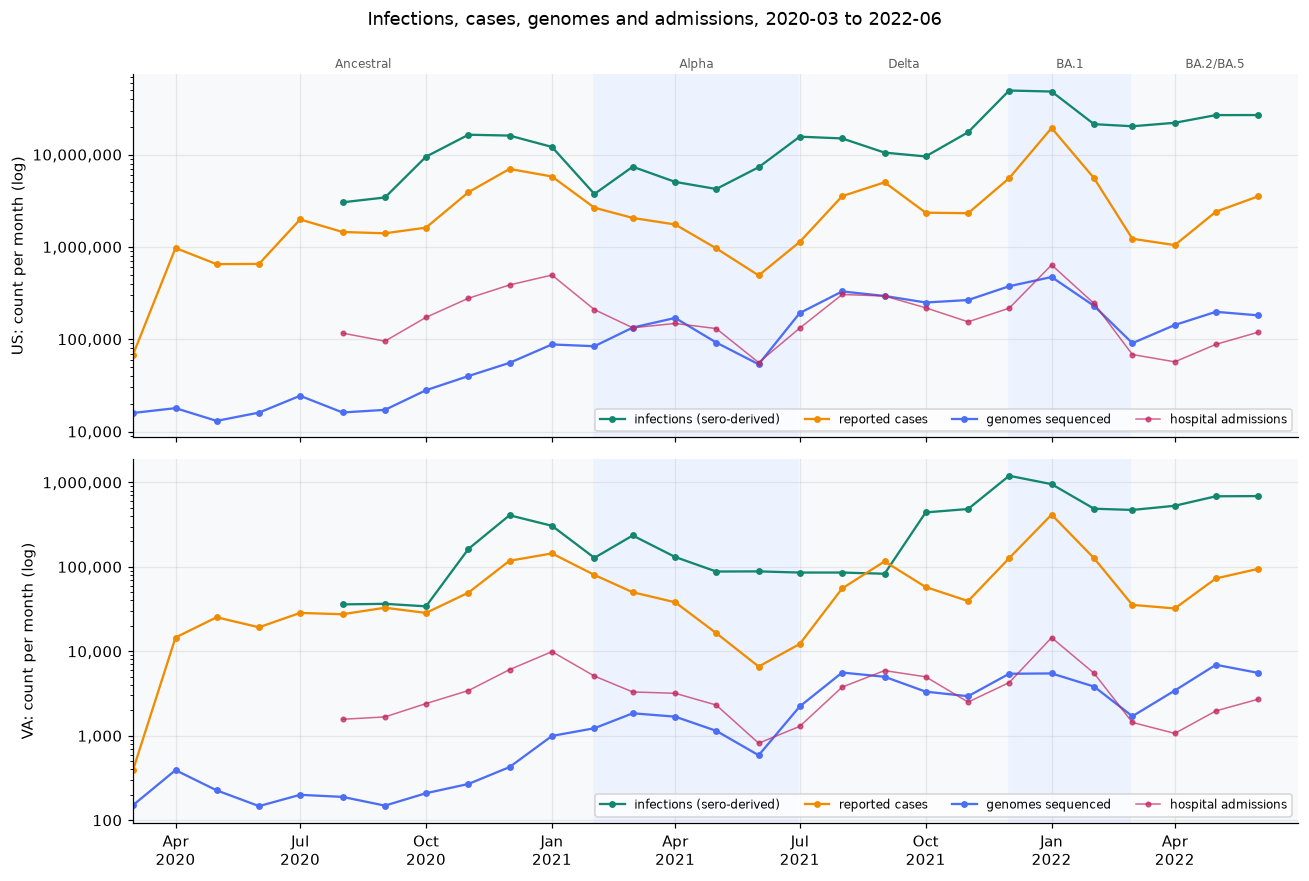

In [7]:
def shade_eras(ax):
    for (name, lo, hi), colr in zip(ad.VARIANT_ERAS, ERA_SHADE):
        ax.axvspan(pd.Timestamp(lo), pd.Timestamp(hi), color=colr, zorder=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, (geo, labs) in zip(axes, [('US', ['US · GISAID']),
                                  ('VA', ['VA · GISAID', 'VA · reconciled'])]):
    p = panels[labs[0]]          # denominators are shared within a geography
    shade_eras(ax)
    ax.plot(p.index, p.infections, 'o-', ms=3.5, color=COL['infections'], label='infections (sero-derived)')
    ax.plot(p.index, p.reported_cases, 'o-', ms=3.5, color=COL['cases'], label='reported cases')
    ax.plot(p.index, p.hosp_admissions, 'o-', ms=3, color=COL['hosp'], lw=1, alpha=.7, label='hospital admissions')
    for lab, style in zip(labs, ['o-', 's--']):
        tag = lab.split('·')[1].strip()
        ax.plot(panels[lab].index, panels[lab].n_sequences, style, ms=3.5,
                color=GENOME_COLORS[tag], label=f'genomes · {tag}')
    ax.set_yscale('log')
    ax.set_ylabel(f'{geo}: count per month (log)')
    ax.legend(fontsize=8, ncol=5, loc='lower right')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))

for (name, lo, hi), short in zip(ad.VARIANT_ERAS, ERA_SHORT):
    mid = pd.Timestamp(lo) + (pd.Timestamp(hi) - pd.Timestamp(lo)) / 2
    axes[0].annotate(short, xy=(mid, 1.0), xycoords=('data', 'axes fraction'),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=8, color='0.35')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[1].set_xlim(ad.WINDOW_START, ad.WINDOW_END)
fig.suptitle('Infections, cases, genomes and admissions, 2020-03 to 2022-06', y=0.995)
fig.tight_layout()
fig.savefig(f'{RESULTS}/series_overview.png', bbox_inches='tight')
plt.show()

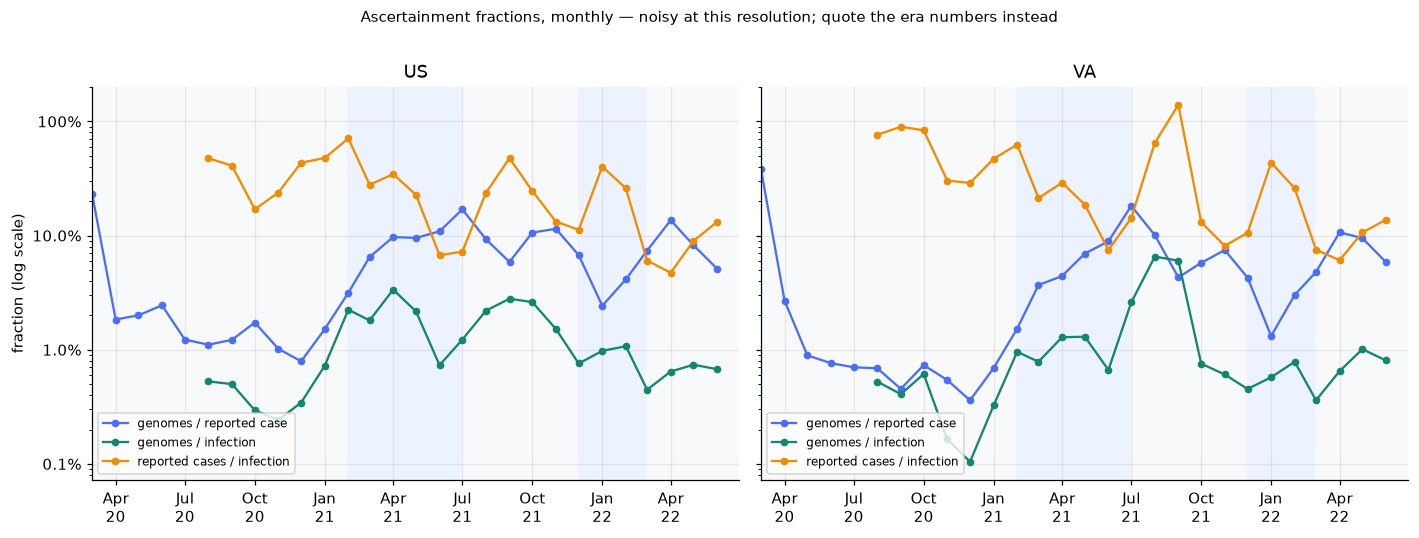

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True)
for ax, (geo, labs) in zip(axes, [('US', ['US · GISAID']),
                                  ('VA', ['VA · GISAID', 'VA · reconciled'])]):
    shade_eras(ax)
    p = panels[labs[0]]
    # Source-independent, so drawn once per geography.
    ax.plot(p.index, p.case_ascertainment, 'o-', ms=4, color=COL['cases'],
            label='reported cases / infection')
    # Colour = which ratio; line style + shade = which genome source.
    for lab, ls, alpha in zip(labs, ['-', '--'], [1.0, 0.55]):
        q, tag = panels[lab], lab.split('·')[1].strip()
        ax.plot(q.index, q.frac_cases_sequenced, ls, marker='o', ms=3.5, alpha=alpha,
                color=COL['sequences'], label=f'genomes / case · {tag}')
        ax.plot(q.index, q.frac_infections_sequenced, ls, marker='s', ms=3.5, alpha=alpha,
                color=COL['infections'], label=f'genomes / infection · {tag}')
    ax.set_yscale('log')
    ax.set_title(geo)
    # Spans three decades, so label decades only -- minor labels would collide.
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.1%}' if v < 1 else f'{v:.0%}'))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))
    ax.set_xlim(ad.WINDOW_START, ad.WINDOW_END)
axes[0].set_ylabel('fraction (log scale)')

# One legend for both panels, below the axes so it cannot sit on the data.
handles, labels_ = axes[1].get_legend_handles_labels()
fig.legend(handles, labels_, fontsize=8, ncol=3, loc='upper center',
           bbox_to_anchor=(0.5, 0.04), frameon=False)
fig.suptitle('Ascertainment fractions, monthly — noisy at this resolution; quote the era numbers instead',
             y=1.01, fontsize=10)
fig.tight_layout(rect=[0, 0.10, 1, 1])
fig.savefig(f'{RESULTS}/fractions_monthly.png', bbox_inches='tight')
plt.show()

## 5. Era-level summary — the numbers to quote

Monthly ratios swing by a factor of several for reasons that have nothing to do with surveillance effort: the survey
rounds are irregular and differencing a cumulative curve amplifies sampling error. Summing counts over a whole variant
era *first*, then taking the ratio, is far more stable. Era infections are read off the cumulative curve at the era
boundaries rather than summed from monthly differences, which is what makes the first era usable — cumulative infection
at 2020-03-01 is effectively zero, so the curve's level at the era end is the era's infection count even though the
survey did not start until July 2020.

All three series are tabulated and plotted. In the bar chart the third panel shows only two bars: reported cases per
infection has no genome term, so `VA · GISAID` and `VA · reconciled` are identical there by construction and drawing both
would imply a difference that does not exist.

In [9]:
era_show = ['months', 'n_sequences', 'reported_cases', 'hosp_admissions', 'infections',
            'frac_infections_sequenced', 'frac_cases_sequenced', 'case_ascertainment', 'infections_per_case']

def fmt_era(e):
    out = e[era_show].copy()
    for col in ['n_sequences', 'reported_cases', 'hosp_admissions', 'infections']:
        out[col] = out[col].map(lambda v: f'{v:,.0f}' if pd.notna(v) else '-')
    for col in ['frac_infections_sequenced', 'frac_cases_sequenced', 'case_ascertainment']:
        out[col] = out[col].map(lambda v: f'{v:.2%}' if pd.notna(v) else '-')
    out['infections_per_case'] = out['infections_per_case'].map(lambda v: f'{v:.1f}x')
    return out

for lab in SERIES:
    print(f'===  {lab}  ===')
    display(fmt_era(eras[lab]))

===  UNITED STATES  ===


,months,n_sequences,reported_cases,hosp_admissions,infections,frac_infections_sequenced,frac_cases_sequenced,case_ascertainment,infections_per_case
era,,,,,,,,,
Ancestral / pre-VOC,11,"331,596","25,508,173","1,544,812","81,646,850",0.41%,1.30%,31.24%,3.2x
Alpha (B.1.1.7),5,"533,164","7,926,222","676,703","27,741,069",1.92%,6.73%,28.57%,3.5x
Delta (B.1.617.2),5,"1,331,265","14,353,864","1,104,105","68,165,181",1.95%,9.27%,21.06%,4.7x
Omicron BA.1,3,"1,076,519","30,541,456","1,098,715","119,110,717",0.90%,3.52%,25.64%,3.9x
Omicron BA.2 / BA.5,4,"612,591","8,211,486","332,209","96,031,961",0.64%,7.46%,8.55%,11.7x


===  VIRGINIA  ===


,months,n_sequences,reported_cases,hosp_admissions,infections,frac_infections_sequenced,frac_cases_sequenced,case_ascertainment,infections_per_case
era,,,,,,,,,
Ancestral / pre-VOC,11,"3,354","488,537","25,061","1,391,094",0.24%,0.69%,35.12%,2.8x
Alpha (B.1.1.7),5,"6,491","191,373","14,706","670,194",0.97%,3.39%,28.55%,3.5x
Delta (B.1.617.2),5,"19,096","280,798","18,477","1,178,880",1.62%,6.80%,23.82%,4.2x
Omicron BA.1,3,"14,723","668,527","24,289","2,638,031",0.56%,2.20%,25.34%,3.9x
Omicron BA.2 / BA.5,4,"17,613","235,292","7,189","2,372,910",0.74%,7.49%,9.92%,10.1x


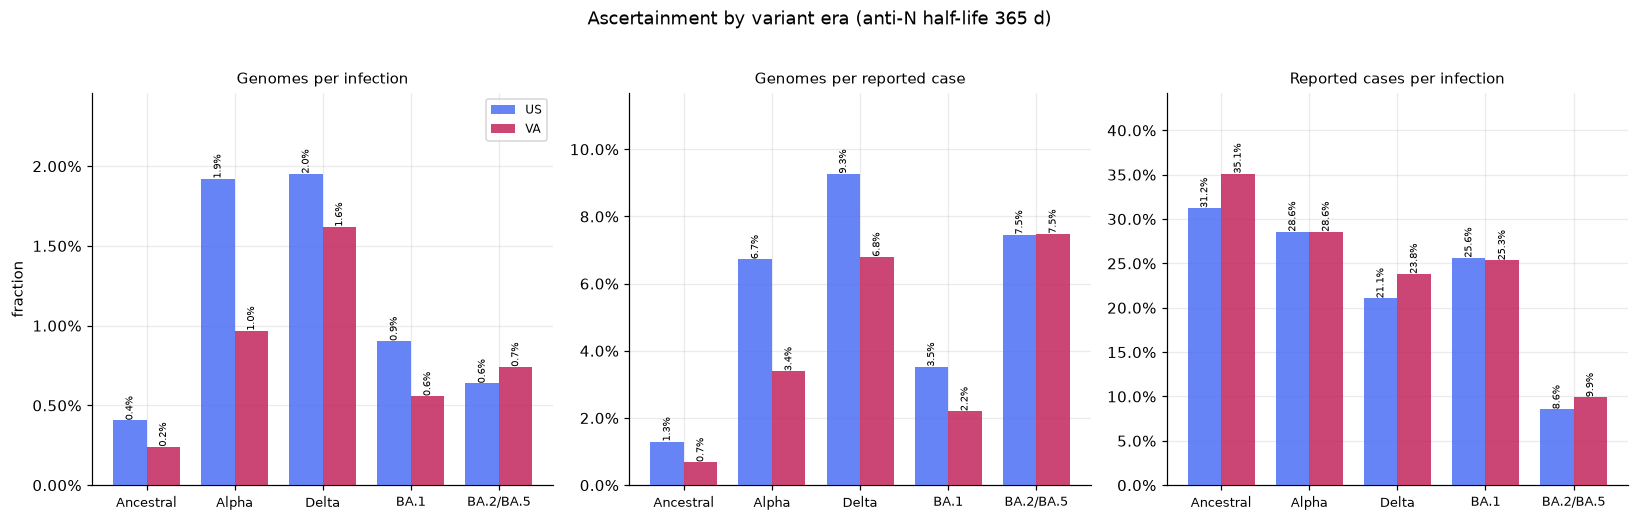

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
metrics = [('frac_infections_sequenced', 'Genomes per infection', list(SERIES)),
           ('frac_cases_sequenced', 'Genomes per reported case', list(SERIES)),
           # No genomes in this ratio, so the two VA series are identical --
           # drawing both would imply a difference that does not exist.
           ('case_ascertainment', 'Reported cases per infection\n(genome source not involved)',
            ['US · GISAID', 'VA · GISAID'])]
x = np.arange(len(ERA_NAMES))

for ax, (metric, title, labs) in zip(axes, metrics):
    w = 0.8 / len(labs)
    for i, lab in enumerate(labs):
        vals = eras[lab][metric].reindex(ERA_NAMES).to_numpy(dtype=float)
        off = (i - (len(labs) - 1) / 2) * w
        name = lab.split('·')[0].strip() if metric == 'case_ascertainment' else lab
        bars = ax.bar(x + off, vals, w, label=name, color=SERIES_COLORS[lab], alpha=.9, zorder=3)
        for b, v in zip(bars, vals):
            if np.isfinite(v):
                ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1%}', ha='center',
                        va='bottom', fontsize=6.4, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels(ERA_SHORT, fontsize=8.5)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.margins(y=.28)
    ax.legend(fontsize=7.5)
axes[0].set_ylabel('fraction')
fig.suptitle(f'Ascertainment by variant era (anti-N half-life {HALFLIFE} d)', y=1.02)
fig.tight_layout()
fig.savefig(f'{RESULTS}/fractions_by_era.png', bbox_inches='tight')
plt.show()

## 6. Sensitivity: how much does the seroreversion assumption move this?

The infection denominator is the soft part of the calculation. `None` means take the measured cumulative anti-N curve at
face value; 365 d and 180 d progressively inflate it to undo antibody waning. Note what happens with **no** correction:
the Alpha era returns a case ascertainment above 1 and a higher genomes-per-infection than genomes-per-case — both
impossible, since sequences are drawn from reported cases. That internal contradiction is the evidence that some
seroreversion correction is required, not optional.

The half-life assumption moves the *denominator*, so it shifts both Virginia genome sources by the same factor. Comparing
the two VA panels below therefore isolates the effect of the genome source alone.

In [11]:
sens = []
for hl in [None, 545, 365, 180]:
    for lab, (geo, src) in SERIES.items():
        p = ad.build_monthly_panel(geo, seroreversion_halflife_days=hl, sequence_source=src)
        e = ad.build_era_panel(p, geo, seroreversion_halflife_days=hl)
        for era_name, row in e.iterrows():
            sens.append({'half_life_days': 'none' if hl is None else hl,
                         'series': lab, 'geo': geo, 'sequence_source': src, 'era': era_name,
                         'infections': row.infections,
                         'frac_infections_sequenced': row.frac_infections_sequenced,
                         'case_ascertainment': row.case_ascertainment})
sens = pd.DataFrame(sens)

# Case ascertainment has no genome term, so report it once per geography.
pivot = (sens[sens.sequence_source == 'gisaid']
         .pivot_table(index=['geo', 'era'], columns='half_life_days',
                      values='case_ascertainment', sort=False))
print('Case ascertainment (reported cases / infection) by seroreversion half-life:')
display(pivot.map(lambda v: f'{v:.1%}' if pd.notna(v) else '-'))

impossible = sens[sens.case_ascertainment > 1].drop_duplicates(['half_life_days', 'geo', 'era'])
print('\nEra/assumption combinations giving impossible ascertainment > 1:')
display(impossible[['half_life_days', 'geo', 'era', 'case_ascertainment']].round(3))

Case ascertainment (reported cases / infection) by seroreversion half-life:


half_life_days             none    545    365    180
geo era                                             
US  Ancestral / pre-VOC   37.7%  33.1%  31.2%  26.6%
    Alpha (B.1.1.7)      105.2%  37.6%  28.6%  16.4%
    Delta (B.1.617.2)     35.6%  24.3%  21.1%  14.8%
    Omicron BA.1          33.9%  27.9%  25.6%  20.5%
    Omicron BA.2 / BA.5   18.7%  10.4%   8.6%   5.5%
VA  Ancestral / pre-VOC   41.6%  37.0%  35.1%  30.3%
    Alpha (B.1.1.7)       68.4%  35.4%  28.6%  17.9%
    Delta (B.1.617.2)     39.0%  27.3%  23.8%  17.0%
    Omicron BA.1          32.6%  27.4%  25.3%  20.6%
    Omicron BA.2 / BA.5   18.5%  11.7%   9.9%   6.7%


Era/assumption combinations giving impossible ascertainment > 1:


,half_life_days,geo,era,case_ascertainment
1,none,US,Alpha (B.1.1.7),1.052


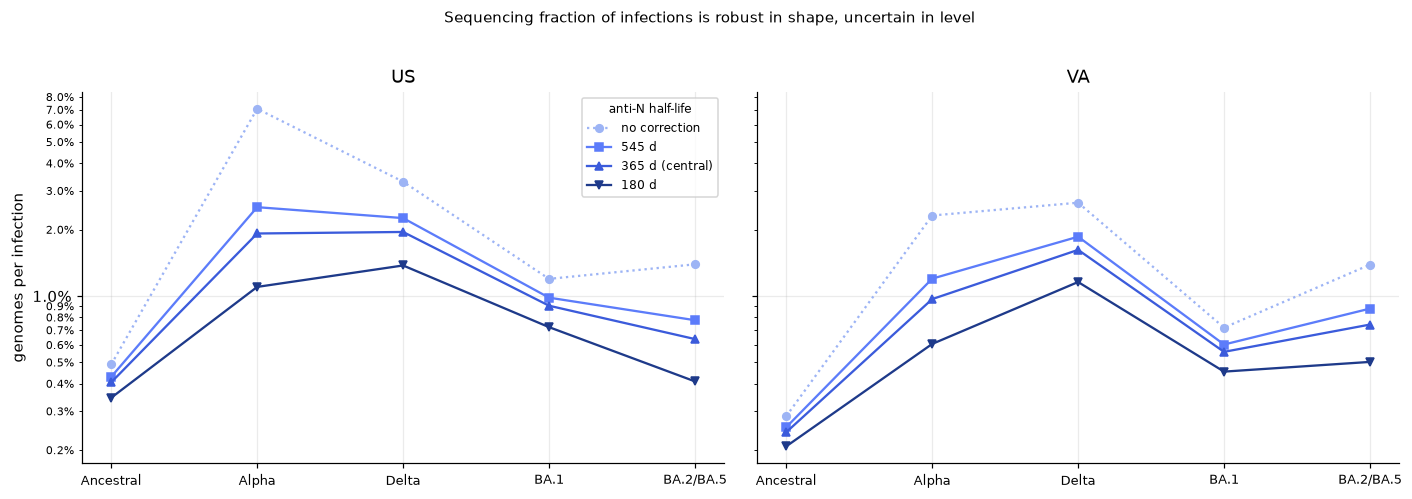

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
order = ERA_NAMES
# Half-life is an ordinal assumption, so ramp the colour with it.
ramp = ['#9DB4F5', '#5C7CFA', '#3B5BDB', '#1E3A8A']
for ax, lab in zip(axes, SERIES):
    s = sens[sens.series == lab]
    for (hl, style, colr, hl_lab) in zip(['none', 545, 365, 180], ['o:', 's-', '^-', 'v-'], ramp,
                                         ['no correction', '545 d', '365 d (central)', '180 d']):
        sub = s[s.half_life_days == hl].set_index('era').reindex(order)
        ax.plot(range(len(order)), sub.frac_infections_sequenced, style, ms=5,
                color=colr, label=hl_lab)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(ERA_SHORT, fontsize=8)
    ax.set_yscale('log'); ax.set_title(lab)
    # A log axis labels minor ticks too; format both or they render as 6x10^-2.
    pct = FuncFormatter(lambda v, _: f'{v:.1%}')
    ax.yaxis.set_major_formatter(pct); ax.yaxis.set_minor_formatter(pct)
    ax.tick_params(axis='y', which='minor', labelsize=7)
axes[0].set_ylabel('genomes per infection')
axes[0].legend(fontsize=8, title='anti-N half-life', title_fontsize=8)
fig.suptitle('Sequencing fraction of infections is robust in shape, uncertain in level', y=1.02, fontsize=10)
fig.tight_layout()
fig.savefig(f'{RESULTS}/sensitivity_seroreversion.png', bbox_inches='tight')
plt.show()

The *ordering* across eras barely moves — Delta is the best-sequenced era and BA.2/BA.5 the worst under every assumption —
while the *level* moves by a factor of ~2 between the extremes. Treat the era ranking as solid and the absolute
percentages as order-of-magnitude.

## 7. Three counts of Virginia's genomes

`all_variants.csv` counts genomes *deposited to GISAID*. Virginia has two further tallies of its own, and they answer a
different question — how many genomes the state sequenced, deposited or not:

| Label | File | What it is |
|---|---|---|
| **GISAID** | `variants/all_variants.csv` | outbreak.info extract of GISAID deposits. National coverage, no age. |
| **VDH NCBI** | `VDH_genomics/Genomic Data NCBI_2025-01-03.csv` | VDH line list linked to NCBI. VA only, has numeric age. |
| **Reconciled list** | `ncbi_source_results/genomic_update_2024_05_18.extra.csv` | VDH's reconciliation of NCBI, GISAID and in-state records. VA only, has numeric age. |

### Both VDH files need de-duplicating before they can be counted

Neither is one-row-per-genome. They are merge outputs, and the join fanned out: in the reconciled file a single GenBank
accession carries up to **5** different GISAID ids and a single GISAID id up to **11** accessions, with collection date,
specimen id and even patient age varying inside what is nominally one accession's rows. No single identifier column is a
safe key.

So rows are linked into genomes by **connected components** — two rows are the same genome if they share *any* identifier
(`accession`, `gisaid_accession_id`, `isolate`, `specimen_id`, `sequence_id`, `vendor_id`). The linkage stays local rather
than chaining everything together: 109,387 rows collapse to 97,626 genomes, 88,885 of them singletons, largest component
156 rows. Counting raw rows instead overstates the VDH NCBI extract by **12%** over this window.

Two further quirks of the reconciled file, both handled on load: a stray repeated header sits at line 100,001 (it is two
blocks concatenated, sharing no rows), and `Unnamed: 0` is a stale row index that silently defeats `drop_duplicates`.

Its 10,934 identifier-less rows are kept: they carry variant calls, so they are sequenced specimens with no deposited
accession recorded — precisely what a reconciled list is supposed to add over a deposition-based count.

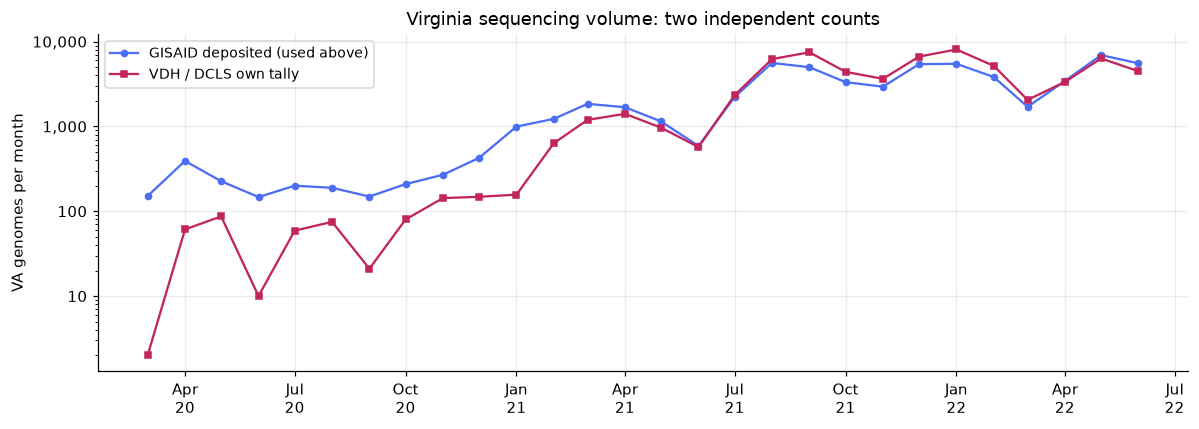

median VDH/GISAID ratio, 2020-03 to 2021-06: 0.38
median VDH/GISAID ratio, Delta onward (2021-07+): 1.22


,gisaid_deposited,vdh_tally,ratio
2020-03-01,151.0,2.0,0.01
2020-04-01,392.0,61.0,0.16
2020-05-01,226.0,87.0,0.38
2020-06-01,147.0,10.0,0.07
2020-07-01,200.0,59.0,0.30
2020-08-01,189.0,75.0,0.40
2020-09-01,149.0,21.0,0.14
2020-10-01,209.0,80.0,0.38
2020-11-01,269.0,143.0,0.53
2020-12-01,426.0,148.0,0.35


In [13]:
seq_sources = {
    'GISAID deposited': ad.monthly_sequence_counts('VA', 'gisaid'),
    'VDH NCBI (linked)': ad.monthly_sequence_counts('VA', 'vdh'),
    'Reconciled list (linked)': ad.monthly_sequence_counts('VA', 'reconciled'),
}
chk = pd.DataFrame(seq_sources).loc['2020-03':'2022-06']
chk['VDH NCBI (raw rows)'] = ad.vdh_sequences_monthly(dedup=False)

SRC_COLORS = {'GISAID deposited': COL['sequences'], 'VDH NCBI (linked)': COL['hosp'],
              'Reconciled list (linked)': COL['infections']}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
for lab, colr in SRC_COLORS.items():
    ax.plot(chk.index, chk[lab], 'o-', ms=4, color=colr, label=lab)
ax.plot(chk.index, chk['VDH NCBI (raw rows)'], ':', lw=1.2, color=COL['hosp'],
        label='VDH NCBI (raw rows, over-counts)')
ax.set_yscale('log'); ax.set_ylabel('VA genomes per month')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))
ax.legend(fontsize=7.5); ax.set_title('Virginia sequencing volume, three sources')

ax = axes[1]
for lab in ['VDH NCBI (linked)', 'Reconciled list (linked)']:
    ax.plot(chk.index, chk[lab] / chk['GISAID deposited'], 'o-', ms=4,
            color=SRC_COLORS[lab], label=f'{lab} / GISAID')
ax.axhline(1.0, color='0.6', lw=.9, ls='--')
ax.axvline(pd.Timestamp('2021-07-01'), color='0.4', ls=':', lw=1)
ax.annotate('Delta onward', xy=(pd.Timestamp('2021-07-15'), 0.02), xycoords=('data', 'axes fraction'),
            fontsize=7.5, color='0.35')
ax.set_ylabel('ratio to GISAID'); ax.set_yscale('log')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))
ax.legend(fontsize=8); ax.set_title('The VDH sources only exceed GISAID after mid-2021')

fig.tight_layout(); fig.savefig(f'{RESULTS}/va_sequence_crosscheck.png', bbox_inches='tight')
plt.show()

for lo, hi, lab in [('2020-03', '2021-06', '2020-03 to 2021-06'),
                    ('2021-07', '2022-06', 'Delta onward')]:
    w = chk.loc[lo:hi]
    print(f'{lab}:  totals  GISAID {w["GISAID deposited"].sum():,.0f} | '
          f'VDH {w["VDH NCBI (linked)"].sum():,.0f} | '
          f'reconciled {w["Reconciled list (linked)"].sum():,.0f}')
    print(f'{"":{len(lab)+1}}  median ratio to GISAID  '
          f'VDH {(w["VDH NCBI (linked)"]/w["GISAID deposited"]).median():.2f} | '
          f'reconciled {(w["Reconciled list (linked)"]/w["GISAID deposited"]).median():.2f}')

**The reconciled list is the largest count from Delta onward, and the direction of the earlier caveat holds — but the
magnitude was inflated by duplicate rows.** Over 2021-07 to 2022-06 the totals are GISAID 51,432, VDH NCBI 53,416 and
reconciled 56,693; median monthly ratios to GISAID are 1.03 and 1.15. So the reconciled list finds about **15% more**
Virginia genomes than GISAID in that period, not the ~20% suggested by the un-de-duplicated VDH count.

**Before mid-2021 both VDH sources fall well below GISAID** — 4,298 and 5,909 against GISAID's 9,845 — because their
variant/lineage linkage for 2020 specimens is sparse. That is under-capture in the VDH files, not over-counting by GISAID.

Practical rule: **GISAID is the better numerator through mid-2021, the reconciled list from Delta onward.** No single source
is best across the whole window, which is why `sequence_source` is a parameter rather than a fixed choice.

### How much does the choice of genome source move the answer?

Only the two ratios with sequences in the numerator are affected; case ascertainment is untouched. Virginia only —
there is no alternative national source.

In [ ]:
src_cmp = {}
for src in ad.SEQUENCE_SOURCES:
    p = ad.build_monthly_panel('VA', seroreversion_halflife_days=HALFLIFE, sequence_source=src)
    e = ad.build_era_panel(p, 'VA', seroreversion_halflife_days=HALFLIFE)
    src_cmp[src] = e[['frac_infections_sequenced', 'frac_cases_sequenced']]

order = [n for n, _, _ in ad.VARIANT_ERAS]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(order)); w = 0.26
bar_colors = {'gisaid': COL['sequences'], 'vdh': COL['hosp'], 'reconciled': COL['infections']}
labels = {'gisaid': 'GISAID', 'vdh': 'VDH NCBI', 'reconciled': 'Reconciled list'}

for ax, metric, title in zip(axes,
                             ['frac_infections_sequenced', 'frac_cases_sequenced'],
                             ['VA genomes per infection', 'VA genomes per reported case']):
    for i, src in enumerate(ad.SEQUENCE_SOURCES):
        v = src_cmp[src][metric].reindex(order)
        ax.bar(x + (i - 1) * w, v, w, color=bar_colors[src], label=labels[src], zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(ERA_SHORT, fontsize=8.5)
    ax.set_title(title); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(fontsize=8)
fig.suptitle('Virginia ascertainment by genome source', y=1.02)
fig.tight_layout(); fig.savefig(f'{RESULTS}/va_source_comparison.png', bbox_inches='tight')
plt.show()

display(pd.concat({labels[s]: src_cmp[s]['frac_infections_sequenced'] for s in ad.SEQUENCE_SOURCES},
                  axis=1).reindex(order).map(lambda v: f'{v:.2%}' if pd.notna(v) else '-'))

## 8. Variant context

CDC's weighted lineage shares are what define the era boundaries used above. Virginia sits in HHS Region 3, so this is the
closest thing to a VA-specific variant series in that dataset — there is no state resolution.

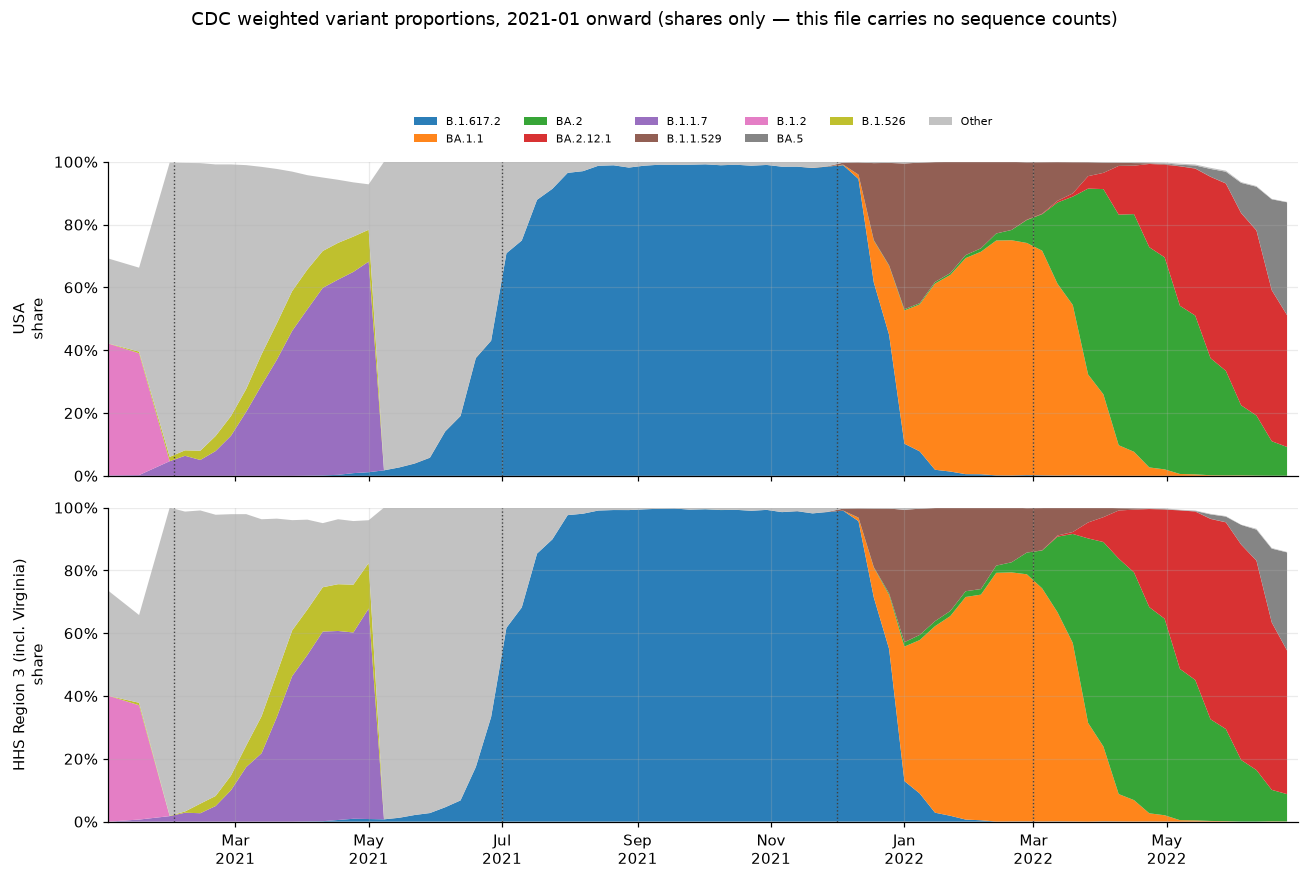

In [14]:
regions = [('USA', 'USA'), ('3', 'HHS Region 3 (incl. Virginia)')]
wides = {}
for region, _ in regions:
    vp = ad.load_cdc_variant_proportions(region)
    vp = vp[(vp.week_ending >= ad.WINDOW_START) & (vp.week_ending <= ad.WINDOW_END)]
    wides[region] = vp.pivot_table(index='week_ending', columns='variant',
                                   values='share', aggfunc='first').fillna(0)

# One lineage -> one colour across both panels, or the same colour would mean
# different variants in each and the comparison would be misleading.
peak = pd.concat([w.max() for w in wides.values()], axis=1).max(axis=1)
keep = [v for v in peak.sort_values(ascending=False).head(10).index if v != 'Other'] + ['Other']
cmap = plt.get_cmap('tab10')
lin_color = {v: cmap(i % 10) for i, v in enumerate(keep[:-1])}
lin_color['Other'] = '0.75'

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
for ax, (region, lab) in zip(axes, regions):
    wide = wides[region].reindex(columns=keep, fill_value=0)
    ax.stackplot(wide.index, wide.T.to_numpy(), labels=keep,
                 colors=[lin_color[v] for v in keep], alpha=.95)
    ax.set_ylim(0, 1); ax.set_ylabel(f'{lab}\nshare')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    for _, lo, hi in ad.VARIANT_ERAS:
        ax.axvline(pd.Timestamp(lo), color='0.25', ls=':', lw=.9)
    ax.margins(x=0)

# The CDC series begins 2021-01, so clip rather than leaving 2020 blank.
axes[0].set_xlim(min(w.index.min() for w in wides.values()), ad.WINDOW_END)
axes[0].legend(fontsize=7.5, ncol=6, loc='lower center', bbox_to_anchor=(.5, 1.02), frameon=False)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
fig.suptitle('CDC weighted variant proportions, 2021-01 onward '
             '(shares only \u2014 this file carries no sequence counts)', y=1.06)
fig.tight_layout(); fig.savefig(f'{RESULTS}/variant_shares.png', bbox_inches='tight')
plt.show()

### 8b. Variant proportions with and without vaccination

The vaccination series is built, corrected and smoothed in `variant_wave_analysis.ipynb`
(section 8b) and exported to `data/vaccination/vaccination_state_weekly_corrected.csv`; this
section only reads it back, so the correction logic lives in exactly one place.

What is plotted is the same CDC weighted variant stack as above, once on its own and once with
vaccination coverage overlaid on the same 0-100% axis — both are population shares, so they
are directly comparable: the line says what fraction of adults were covered while a given
variant held the field.

Coverage here is the **corrected** series (self-report scaled onto the administrative scale by
a per-state factor) expressed as a share of the adult population. Campaigns are drawn as
separate lines rather than one spliced curve: the primary series is cumulative-ever, while each
later campaign restarts from zero every autumn, so a single line would appear to collapse each
fall.

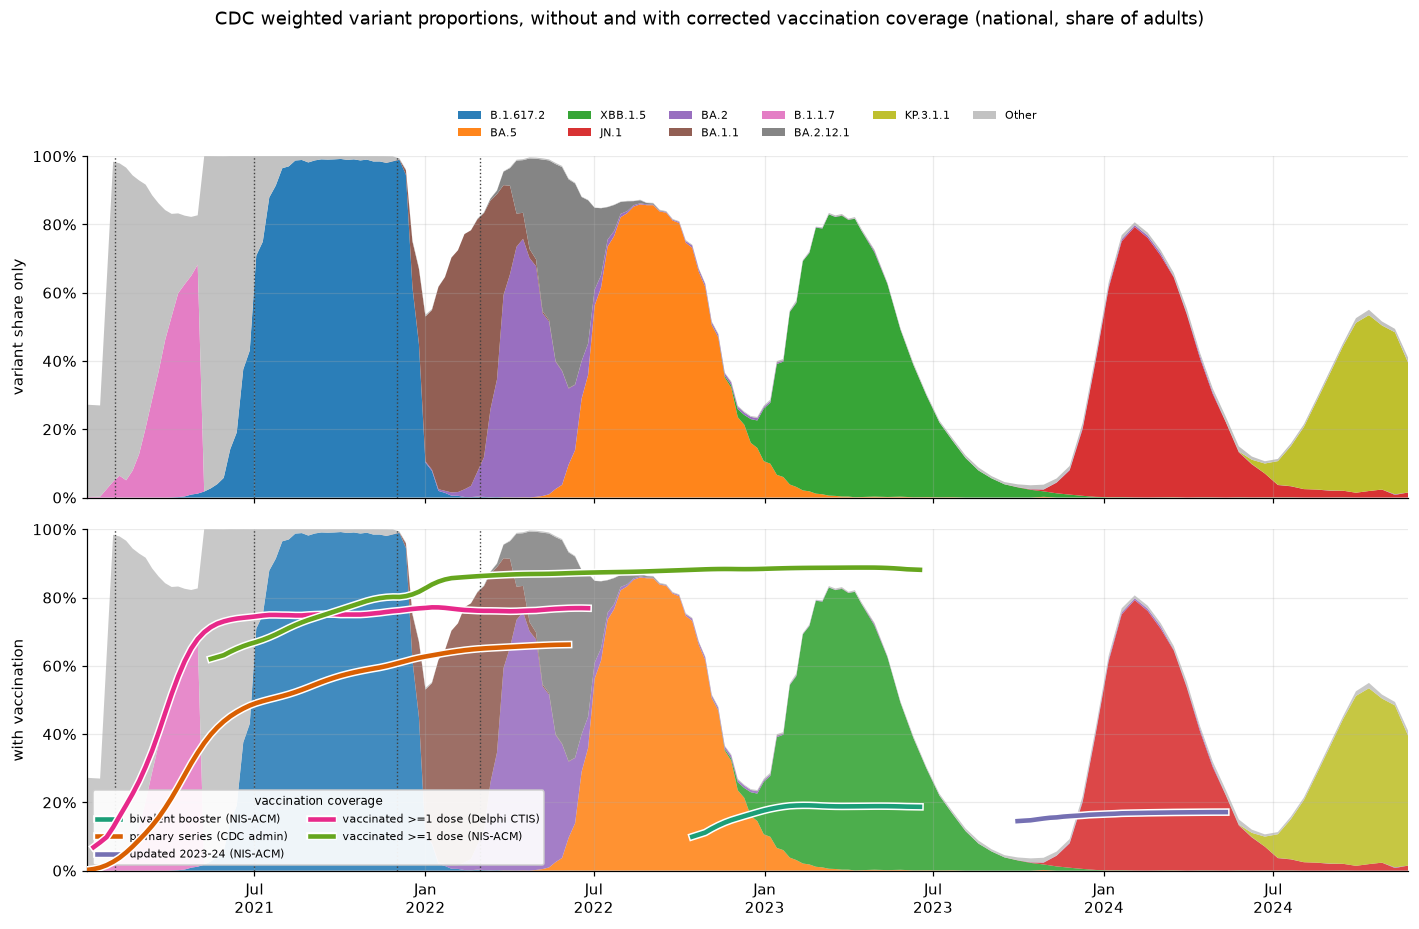

In [15]:
import matplotlib.patheffects as pe
import variant_wave_data as vw

vax_state = vw.load_corrected_vaccination_series()

# Population-weight the states up to a national series (the file carries its own
# denominator so no extra population source is needed).
vax_state['covered'] = vax_state.population_share_smoothed * vax_state.denominator
nat_vax = (vax_state.groupby(['campaign', 'week_ending'])[['covered', 'denominator']].sum())
nat_vax['share'] = nat_vax.covered / nat_vax.denominator

# Same lineage stack as the panel above, USA, but extended past WINDOW_END so the
# later campaigns are visible; the CDC variant file itself runs well beyond it.
vp = ad.load_cdc_variant_proportions('USA')
wide = vp.pivot_table(index='week_ending', columns='variant', values='share',
                      aggfunc='first').fillna(0)
peak = wide.max()
keep = [v for v in peak.sort_values(ascending=False).head(10).index if v != 'Other'] + ['Other']
cmap = plt.get_cmap('tab10')
lin_color = {v: cmap(i % 10) for i, v in enumerate(keep[:-1])}
lin_color['Other'] = '0.75'
wide = wide.reindex(columns=keep, fill_value=0)

vax_cmap = plt.get_cmap('Dark2')
vax_colors = {c: vax_cmap(i % 8) for i, c in enumerate(sorted(nat_vax.index.get_level_values(0).unique()))}

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, with_vax in zip(axes, [False, True]):
    ax.stackplot(wide.index, wide.T.to_numpy(), labels=keep,
                 colors=[lin_color[v] for v in keep], alpha=.85 if with_vax else .95)
    if with_vax:
        # Only the vaccination lines go in this panel's legend -- the variant
        # colours are already keyed by the shared legend above, and repeating
        # all ten of them here covered most of the plot.
        vax_handles = []
        for campaign, s in nat_vax.groupby(level='campaign'):
            s = s.droplevel(0).sort_index()
            (ln,) = ax.plot(s.index, s['share'], lw=3, color=vax_colors[campaign],
                            label=campaign.replace(vw.VAX_PREFIX, ''), zorder=10,
                            path_effects=[pe.Stroke(linewidth=5, foreground='white'), pe.Normal()])
            vax_handles.append(ln)
        ax.legend(handles=vax_handles, fontsize=7.5, ncol=2, loc='lower left',
                  framealpha=.92, title='vaccination coverage', title_fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('with vaccination' if with_vax else 'variant share only')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    for _, lo, hi in ad.VARIANT_ERAS:
        ax.axvline(pd.Timestamp(lo), color='0.25', ls=':', lw=.9)
    ax.margins(x=0)

axes[0].set_xlim(wide.index.min(), max(wide.index.max(), nat_vax.index.get_level_values(1).max()))
axes[0].legend(fontsize=7.5, ncol=6, loc='lower center', bbox_to_anchor=(.5, 1.02), frameon=False)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
fig.suptitle('CDC weighted variant proportions, without and with corrected vaccination coverage '
             '(national, share of adults)', y=1.05)
fig.tight_layout()
fig.savefig(f'{RESULTS}/variant_shares_with_vaccination.png', bbox_inches='tight')
plt.show()

## 9. Do NSSP ED visits and CDC reported cases ever overlap?

Yes — **33 weeks, 2022-10-01 to 2023-05-13**, using the NSSP *trajectories* dataset (`rdmq-nq56`, starts 2022-10-01) rather
than the NSSP summary dataset (`vutn-jzwm`, starts 2023-10-07). The CDC weekly case series stops with the week ending 2023-05-10, which after the
three-day alignment shift below closes the window at 2023-05-13.

The overlap sits entirely **after** the 2020 – mid-2022 ascertainment window, so it adds nothing to the estimates above. What
it is good for is calibration: it is the only stretch where a testing-dependent signal (reported cases) and a
healthcare-utilisation signal (`percent_visits_covid`, the share of ED visits with diagnosed COVID) can be compared directly.

One alignment detail: NSSP weeks end Saturday and CDC case weeks end Wednesday, so the case index is shifted forward three
days to close the same seven-day span.

In [16]:
ov = {geo: ad.nssp_vs_reported_cases(geo) for geo in ['US', 'VA']}

summary = []
for geo, d in ov.items():
    summary.append({
        'geo': geo, 'weeks': len(d),
        'start': d.index.min().date(), 'end': d.index.max().date(),
        'pearson_r': d.ed_pct_covid.corr(d.reported_cases),
        'loglog_r': np.log(d.ed_pct_covid).corr(np.log(d.reported_cases)),
        'cases_per_1pct_ed_median': d.cases_per_1pct_ed.median(),
        'ratio_first4wk': d.cases_per_1pct_ed.iloc[:4].mean(),
        'ratio_last4wk': d.cases_per_1pct_ed.iloc[-4:].mean(),
    })
summary = pd.DataFrame(summary).set_index('geo')
summary['ratio_drift'] = summary.ratio_last4wk / summary.ratio_first4wk - 1
display(summary.round(3))

,weeks,start,end,pearson_r,loglog_r,cases_per_1pct_ed_median,ratio_first4wk,ratio_last4wk,ratio_drift
geo,,,,,,,,,
US,33,2022-10-01,2023-05-13,0.939,0.972,139695.109,169244.956,126907.677,-0.25
VA,33,2022-10-01,2023-05-13,0.919,0.969,3325.455,4086.891,3189.426,-0.22


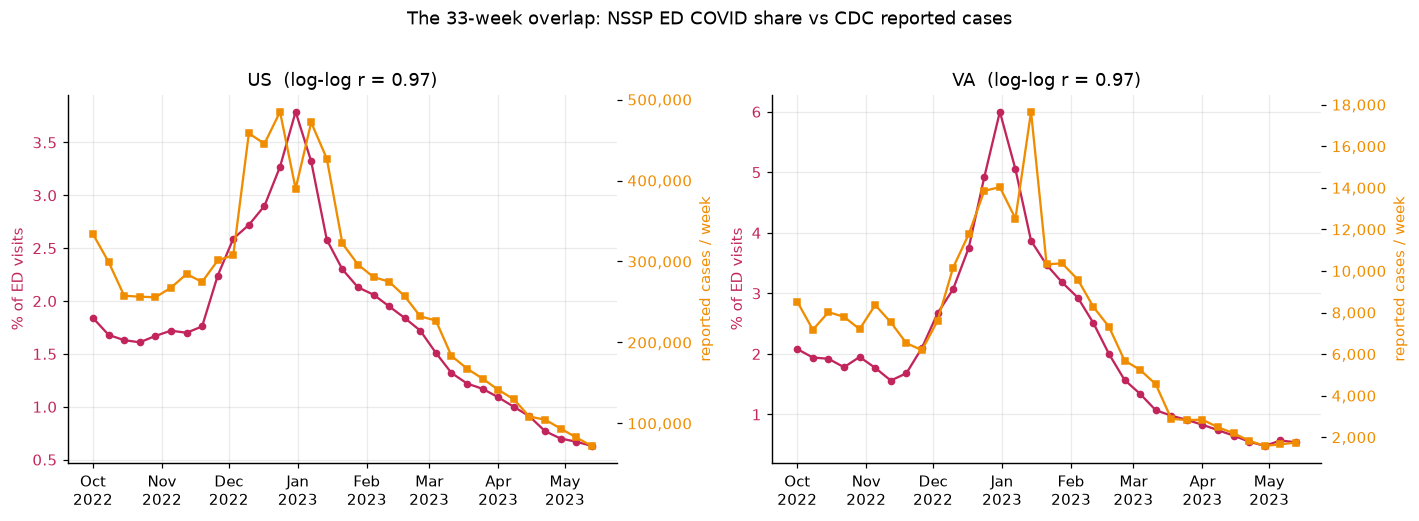

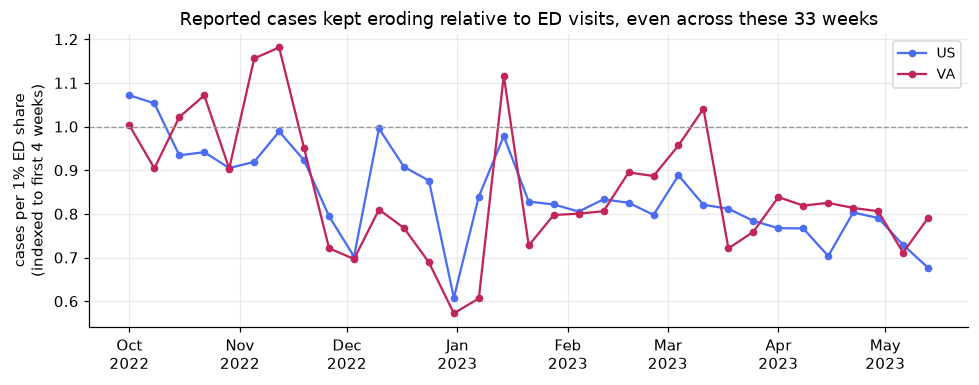

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ax, geo in zip(axes, ['US', 'VA']):
    d = ov[geo]
    ax.plot(d.index, d.ed_pct_covid, 'o-', ms=4, color=COL['hosp'], label='ED visits with COVID (%)')
    ax.set_ylabel('% of ED visits', color=COL['hosp'])
    ax.tick_params(axis='y', labelcolor=COL['hosp'])
    ax2 = ax.twinx()
    ax2.plot(d.index, d.reported_cases, 's-', ms=4, color=COL['cases'], label='reported cases')
    ax2.set_ylabel('reported cases / week', color=COL['cases'])
    ax2.tick_params(axis='y', labelcolor=COL['cases'])
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax2.grid(False)
    ax.set_title(f'{geo}  (log-log r = {np.log(d.ed_pct_covid).corr(np.log(d.reported_cases)):.2f})')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
fig.suptitle('The 33-week overlap: NSSP ED COVID share vs CDC reported cases', y=1.02)
fig.tight_layout()
fig.savefig(f'{RESULTS}/nssp_case_overlap.png', bbox_inches='tight')
plt.show()

# Ratio drift: how many reported cases accompany each 1% of ED visits.
fig, ax = plt.subplots(figsize=(9, 3.6))
for geo, colr in [('US', COL['us']), ('VA', COL['va'])]:
    d = ov[geo]
    ax.plot(d.index, d.cases_per_1pct_ed / d.cases_per_1pct_ed.iloc[:4].mean(),
            'o-', ms=4, color=colr, label=geo)
ax.axhline(1.0, color='0.6', lw=.9, ls='--')
ax.set_ylabel('cases per 1% ED share\n(indexed to first 4 weeks)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.legend(fontsize=9)
ax.set_title('Reported cases kept eroding relative to ED visits, even across these 33 weeks')
fig.tight_layout()
fig.savefig(f'{RESULTS}/nssp_case_ratio_drift.png', bbox_inches='tight')
plt.show()

The two track each other closely in shape — log-log correlation **0.97 (US)** and **0.97 (VA)** across the 33 weeks — so ED
visits are a usable stand-in for case trends once cases stop being reported.

The level is not stable, though. The number of reported cases accompanying each 1% of COVID ED visits **fell about 25%
nationally** between the first and last four weeks of the overlap (roughly 169k → 127k). Over seven months, in a period with
no major variant transition, that is reported cases continuing to erode against a signal that does not depend on anyone
choosing to test. It is the same effect that drives case ascertainment down to 8.6% by the BA.2/BA.5 era in section 5, still
running well after the analysis window closes.

Practical consequence: a single conversion factor from ED share to cases will not hold for long. Anything that splices these
two series needs a time-varying scaling, anchored on a denominator that is not itself testing-dependent.

## 10. Age stratification

Three of the four sources carry age, and they harmonise onto the same four bands — which makes age-stratified **case
ascertainment** computable directly.

| Source | Native age detail | Harmonises to | Geography |
|---|---|---|---|
| Commercial Lab seroprevalence | 0-4, 5-11, 12-17, **0-17**, **18-49**, **50-64**, **65+** | all four bands | state + US |
| Case surveillance (`PU_linelist_agg_cases`) | 0-17, 18-49, 50-64, 65+ | all four bands | county |
| NSSP ED visits (`7xva-uux8`) | <1, 1-4, 5-17, 18-49, 50-64, 65+ | **adult bands only** | **US only** |
| VDH genomics (Virginia) | `Patient Age In Years`, numeric | all four bands | VA only |
| GISAID / outbreak.info sequences | none | — | — |

**The genomic data does turn out to be age-stratifiable for Virginia.** The commons GISAID extract has no age field, as
expected — but the VDH/DCLS line list carries `Patient Age In Years` as a numeric age, so VA genomes bin exactly onto the
same bands. Age is missing for ~6.4% of sequenced specimens. There is no national equivalent, so
`frac_infections_sequenced` can only be age-split for VA.

### Four data problems that had to be handled first

**1. `666` and `777` are suppression sentinels, not percentages.** Every `rate_*` column in the commercial-lab survey uses
`666` (no specimens collected) and `777` (cell size < 75). They are plain numbers in the CSV, so reading them naively gives
"777% seropositive". They are now masked in both seroprevalence loaders. The all-ages results in sections 3–6 are
unaffected — the sentinel appears in `rate_cumulative_prevalence` for AZ, HI, ND, SD, UT and WY only, never for US or VA —
but this would have silently wrecked the 50-state extension suggested in section 12.

**2. Virginia's 0-17 band is mostly suppressed.** 27 of its 30 rounds, usable only from Nov 2021. So VA paediatric
ascertainment is reported for the Omicron eras and left blank before that. The US 0-17 row has no suppressed rounds.

**3. The case line list is incomplete as a count.** `PU_linelist_agg_cases` holds ~58% of the weekly-series cases
nationally and ~47% in VA, and the shortfall drifts (VA: 55% in 2020 → 40% in 2022). Used raw it would halve case
ascertainment for reasons unrelated to age. It is therefore used for the age *composition* of each month only, and that
composition is applied to the weekly series total — so the bands sum to the same `reported_cases` as the all-ages panel.

**4. NSSP age percentages are within-group and cannot be summed.** `percent_visits` for an age band is the share of ED
visits *in that band* that were COVID-related, not that band's share of COVID visits. For the week ending 2023-01-07 the
bands run 1.3% (5-17) to 6.9% (<1) and add to 21.5%, against an all-ages figure near 3.8%. That also means <1, 1-4 and 5-17
cannot be pooled into 0-17 without ED visit volumes, which the dataset does not publish.

In [18]:
age_panels = {geo: ad.build_age_panel(geo, seroreversion_halflife_days=HALFLIFE) for geo in ['US', 'VA']}
age_eras = {geo: ad.build_age_era_panel(geo, seroreversion_halflife_days=HALFLIFE) for geo in ['US', 'VA']}

print('Population by age band (rescaled to the survey catchment):')
display(ad.fetch_age_populations().loc[['US', 'VA']].round(0))

print('\nUS — case ascertainment by age band and era:')
display((age_eras['US']['case_ascertainment'].unstack('age_band')[ad.AGE_BANDS]
         .reindex([n for n, _, _ in ad.VARIANT_ERAS])
         .map(lambda v: f'{v:.1%}' if pd.notna(v) else '-')))

print('VA — case ascertainment by age band and era ("-" = seroprevalence suppressed):')
display((age_eras['VA']['case_ascertainment'].unstack('age_band')[ad.AGE_BANDS]
         .reindex([n for n, _, _ in ad.VARIANT_ERAS])
         .map(lambda v: f'{v:.1%}' if pd.notna(v) else '-')))

Population by age band (rescaled to the survey catchment):


band,0-17,18-49,50-64,65+
geo,,,,
US,72565061.0,135804466.0,62831280.0,55089164.0
VA,1856586.0,3514402.0,1657183.0,1385603.0



US — case ascertainment by age band and era:


age_band,0-17,18-49,50-64,65+
era,,,,
Ancestral / pre-VOC,11.3%,37.4%,37.5%,43.4%
Alpha (B.1.1.7),14.2%,34.2%,27.5%,30.2%
Delta (B.1.617.2),14.9%,24.0%,21.9%,25.3%
Omicron BA.1,20.6%,28.5%,26.5%,26.7%
Omicron BA.2 / BA.5,6.1%,10.1%,8.5%,9.1%


VA — case ascertainment by age band and era ("-" = seroprevalence suppressed):


age_band,0-17,18-49,50-64,65+
era,,,,
Ancestral / pre-VOC,-,44.5%,43.0%,46.3%
Alpha (B.1.1.7),-,32.8%,17.9%,33.3%
Delta (B.1.617.2),-,23.2%,32.7%,33.8%
Omicron BA.1,17.9%,33.5%,26.9%,17.7%
Omicron BA.2 / BA.5,6.1%,14.5%,7.9%,8.2%


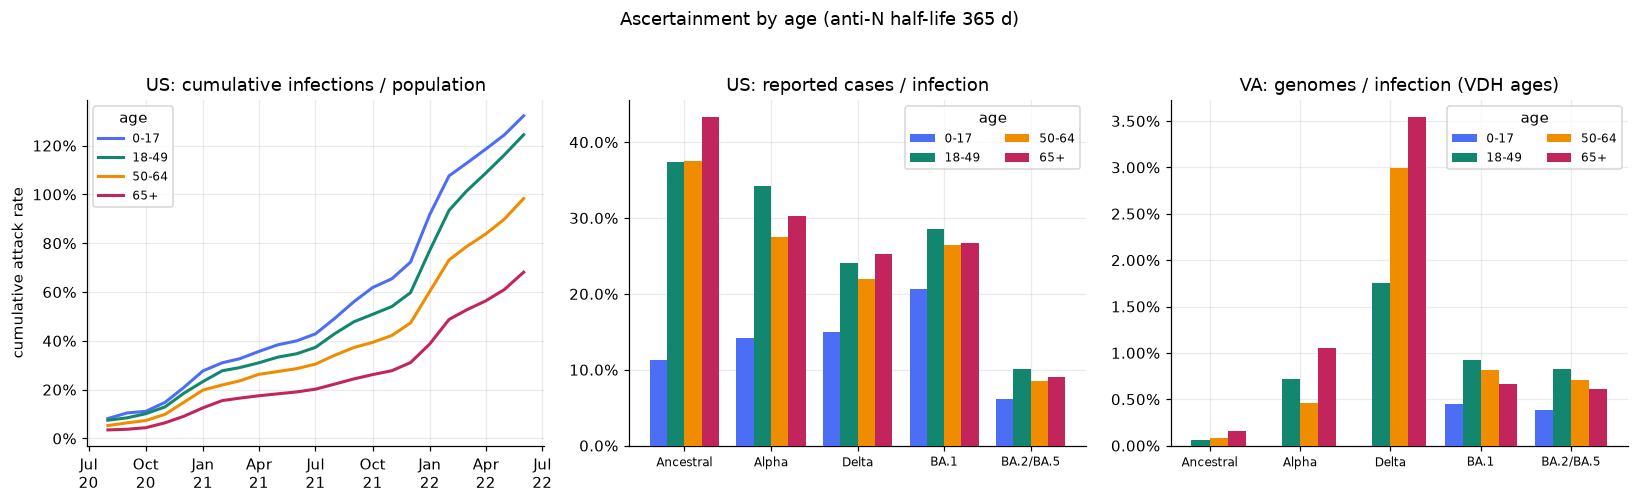

In [19]:
AGE_COLORS = {'0-17': '#4C6EF5', '18-49': '#12866E', '50-64': '#F08C00', '65+': '#C2255C'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) cumulative attack rate by age
ax = axes[0]
for band in ad.AGE_BANDS:
    d = age_panels['US'].xs(band, level='age_band')
    ax.plot(d.index, d.attack_rate, '-', lw=2, color=AGE_COLORS[band], label=band)
ax.set_title('US: cumulative infections / population'); ax.set_ylabel('cumulative attack rate')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y')); ax.legend(fontsize=8, title='age')

# (b) case ascertainment by age and era
ax = axes[1]
order = [n for n, _, _ in ad.VARIANT_ERAS]
x = np.arange(len(order)); w = 0.2
for i, band in enumerate(ad.AGE_BANDS):
    v = age_eras['US']['case_ascertainment'].unstack('age_band')[band].reindex(order)
    ax.bar(x + (i - 1.5) * w, v, w, color=AGE_COLORS[band], label=band, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(ERA_SHORT, fontsize=8)
ax.set_title('US: reported cases / infection'); ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(fontsize=8, title='age', ncol=2)

# (c) VA genomes per infection by age
ax = axes[2]
for i, band in enumerate(ad.AGE_BANDS):
    v = age_eras['VA']['frac_infections_sequenced'].unstack('age_band')[band].reindex(order)
    ax.bar(x + (i - 1.5) * w, v, w, color=AGE_COLORS[band], label=band, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(ERA_SHORT, fontsize=8)
ax.set_title('VA: genomes / infection (VDH ages)')
ax.yaxis.set_major_formatter(PercentFormatter(1.0)); ax.legend(fontsize=8, title='age', ncol=2)

fig.suptitle(f'Ascertainment by age (anti-N half-life {HALFLIFE} d)', y=1.03)
fig.tight_layout(); fig.savefig(f'{RESULTS}/age_stratified.png', bbox_inches='tight')
plt.show()

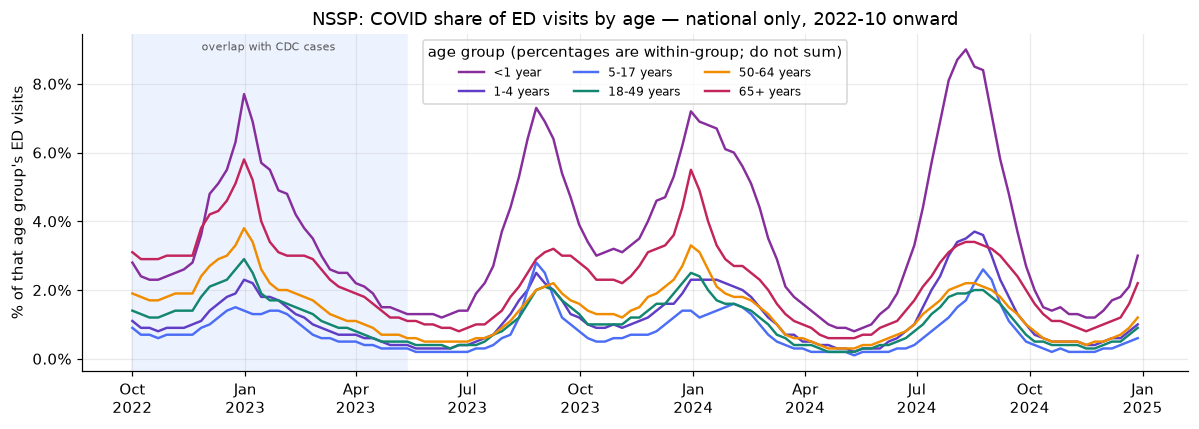

In [20]:
# NSSP by age: national only, and it starts after the analysis window.
nssp_age = ad.fetch_nssp_by_age()
nssp_age = nssp_age[(nssp_age.pathogen == 'COVID-19')
                    & (nssp_age.week_end <= '2024-12-31')]

fig, ax = plt.subplots(figsize=(11, 4))
native_colors = {'<1 year': '#862E9C', '1-4 years': '#5F3DC4', '5-17 years': '#4C6EF5',
                 '18-49 years': '#12866E', '50-64 years': '#F08C00', '65+ years': '#C2255C'}
for grp, colr in native_colors.items():
    d = nssp_age[nssp_age.age_group == grp].sort_values('week_end')
    ax.plot(d.week_end, d.percent_visits, '-', lw=1.6, color=colr, label=grp)
ax.axvspan(pd.Timestamp('2022-10-01'), pd.Timestamp('2023-05-13'), color='#EDF2FF', zorder=0)
ax.text(pd.Timestamp('2023-01-20'), ax.get_ylim()[1]*.95, 'overlap with CDC cases',
        ha='center', fontsize=7.5, color='0.35')
ax.set_ylabel('% of that age group\'s ED visits')
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.legend(fontsize=8, ncol=3, title='age group (percentages are within-group; do not sum)')
ax.set_title('NSSP: COVID share of ED visits by age — national only, 2022-10 onward')
fig.tight_layout(); fig.savefig(f'{RESULTS}/nssp_by_age.png', bbox_inches='tight')
plt.show()

### What the age split shows

**Case ascertainment had a steep age gradient, and it was widest early.** In the pre-variant era the US reported about
**11% of infections in children** against **43% in the 65+ group** — a near four-fold difference. Children were both less
likely to be symptomatic and far less likely to be tested. The gradient narrows as the pandemic goes on (by Omicron BA.1 the
bands sit at 21% / 29% / 26% / 27%) and then collapses together at the bottom in the BA.2/BA.5 era, when home testing pulled
every band down to 6–10%.

**The age gradient in infection runs the opposite way to the gradient in reporting.** Cumulative attack rate by mid-2022 is
highest in 0-17 and lowest in 65+, while ascertainment is lowest in 0-17 and highest in 65+. The two effects compound: the
group with the most infection was the group whose infections were least often recorded.

**Virginia's sequencing skewed towards older patients relative to infection.** In the Delta era genomes per infection run
1.75% (18-49), 2.99% (50-64) and 3.55% (65+) — a two-fold gradient in the direction you would expect if sequencing is drawn
from clinical specimens, which over-represent people sick enough to present for care. The 0-17 band has no Delta value
because VA paediatric seroprevalence is suppressed before Nov 2021; where it can be computed, in the Omicron eras, it is the
lowest band (0.45% and 0.38%, against 0.6–0.9% for the adult bands).

**One caution on the attack-rate panel.** US cumulative attack rate passes 100% for 0-17 and 18-49 by mid-2022 (132% and
125%). That is not an error but it is not "everyone infected" either: these are cumulative *infections*, which count
reinfections, inflated further by the seroreversion correction. Read the panel for the ordering between bands, not as a
share of the population ever infected.

**NSSP adds nothing to the window but is consistent with the story after it.** It is national-only and starts 2022-10, so it
cannot inform 2020 – mid-2022. Where it does exist, the `<1 year` and `65+` bands carry much the highest COVID share of ED
visits, and 5-17 the lowest — the same age gradient in severity that drives the ascertainment gradient above.

## 11. Save outputs

In [21]:
def slug(label):
    return label.replace(' · ', '_').replace('·', '_').replace(' ', '')

for lab in SERIES:                       # US_GISAID, VA_GISAID, VA_reconciled
    panels[lab].to_csv(f'{RESULTS}/monthly_panel_{slug(lab)}.csv')
    eras[lab].to_csv(f'{RESULTS}/era_panel_{slug(lab)}.csv')
for geo in ['US', 'VA']:
    age_panels[geo].to_csv(f'{RESULTS}/age_panel_{geo}.csv')
    age_eras[geo].to_csv(f'{RESULTS}/age_era_panel_{geo}.csv')
sens.to_csv(f'{RESULTS}/seroreversion_sensitivity.csv', index=False)
cov.to_csv(f'{RESULTS}/source_coverage.csv', index=False)

for f in sorted(os.listdir(RESULTS)):
    print(f'  {f:42s} {os.path.getsize(os.path.join(RESULTS, f)):>10,} bytes')

  age_era_panel_US.csv                            2,994 bytes
  age_era_panel_VA.csv                            3,628 bytes
  age_panel_US.csv                               15,511 bytes
  age_panel_VA.csv                               18,270 bytes
  age_stratified.png                            151,293 bytes
  era_panel_US.csv                                1,106 bytes
  era_panel_VA.csv                                1,073 bytes
  fractions_by_era.png                          119,861 bytes
  fractions_monthly.png                         187,231 bytes
  monthly_panel_US.csv                            4,638 bytes
  monthly_panel_VA.csv                            4,394 bytes
  nssp_by_age.png                               181,024 bytes
  nssp_case_overlap.png                         164,803 bytes
  nssp_case_ratio_drift.png                     112,512 bytes
  sensitivity_seroreversion.png                 159,798 bytes
  series_overview.png                           263,223 bytes
  seropr

## 12. What this first pass says

**At best about 1 infection in 50 was sequenced, and for most of the window far fewer.** Under the central 365-day
assumption, US genomes per infection ran **0.41%** in the pre-variant era, peaked at **1.9–2.0%** through Alpha and Delta,
then fell to **0.90%** during Omicron BA.1 and **0.64%** by BA.2/BA.5. Virginia traces the same shape at a lower level:
**0.24% → 0.97% (Alpha) → 1.62% (Delta) → 0.56% (BA.1) → 0.74%**.

**The fall after Delta is not a sequencing-capacity story.** Absolute volume held up — the US sequenced *more* genomes
during BA.1 (1.08M) than during Alpha (533k). What collapsed was the visibility of the denominator: case ascertainment fell
from **28.6%** (Alpha) to **21.1%** (Delta) to **25.6%** (BA.1) and then to **8.6%** (BA.2/BA.5) as home testing displaced
reported PCR. Genomes per *reported case* ended the window far higher than it started (1.3% → 7.5%). After 2021 the binding
constraint on genomic surveillance was not sequencing throughput but how few infections reached the reporting system at all.

**Virginia matches the nation on ascertainment but lags on sequencing depth.** VA case ascertainment sits within ~4 points
of the US in every era (35.1/28.6/23.8/25.3/9.9% vs 31.2/28.6/21.1/25.6/8.6%), while VA genomes per reported case is about
half the national figure during Alpha (3.4% vs 6.7%) and about three-quarters during Delta (6.8% vs 9.3%). That points at
sequencing throughput rather than testing behaviour as the VA-specific gap. Switching the numerator to Virginia's reconciled
list raises the Delta figure to 8.4% and genomes per infection from 1.62% to 1.99% (section 7), narrowing the gap without
closing it. The comparison is not like-for-like, though: the national number has no reconciled equivalent, so some of the
remaining gap is Virginia being measured more completely rather than sequencing more.

### Caveats that matter for how far to push this

- **The infection denominator carries the uncertainty.** Era *ranking* is stable across every seroreversion assumption
  tested; era *levels* move by ~2x. Do not quote these percentages to more than one significant figure.
- **Mar–Jun 2022 rests on a survey splice.** Commercial-lab anti-N stops at round 30; the BA.2/BA.5 era depends on
  increments from a different survey with a different sampled population.
- **Seroprevalence surveys are convenience samples.** Clinical-lab remnant specimens over-represent people with
  healthcare contact; blood donors are healthier and 16+. Neither is a probability sample of the population.
- **Reinfections are invisible to anti-N cumulative prevalence.** A second infection in an already-seropositive person
  does not move the curve, so infections are undercounted from Delta onward — increasingly so through Omicron.

### Reasonable next steps

- Push to **state x era** across all 50 states, which the commercial-lab survey supports directly, and check whether the
  VA sequencing gap is regional or state-specific. Mask `SERO_SENTINELS` first — six states carry `777` in the all-ages
  column, and unmasked it reads as 777% seropositive.
- **Look for reconciled genome lists in other states.** Virginia's adds ~15% over GISAID from Delta onward (section 7).
  If that gap is typical, GISAID-based sequencing fractions are low by a similar margin everywhere.
- Bring in **NHSN admissions as a second, independent denominator** — hospitalisation-based ascertainment is far less
  sensitive to testing behaviour than case-based ascertainment and would help separate the two effects after 2021.
- Extend past mid-2022 using **wastewater** (`NWSS_Public_SARS-CoV-2_Concentration_in_Wastewater_Data.csv`) as the
  denominator once case reporting stops being usable, and pick up **NSSP** from 2023-10 onward.